# Session 4: Fuzzy Terms and Metric Mapping

This notebook converts raw forecast error metrics into linguistic labels for the explanation layer. 

Instead of relying on hard thresholds only, it uses fuzzy membership functions to represent gradual transitions between categories such as low, medium, and high error.

The goal is to map MAE and MPE into human-readable labels that better reflect uncertainty and overlap in model performance. 

By the end of this session, the notebook produces a working fuzzy mapping from metrics to labels like “high error” or “slight underprediction.”


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz

In [2]:
import json

with open("../src/data/metrics_all_models.json") as f:
    metrics = pd.DataFrame(json.load(f))

metrics = metrics.rename(columns={"model": "Model"})
metrics

,Model,MAE,RMSE,MAPE,MPE,DA
0,Naive,781.31,948.15,5.4682,5.4343,0.00
1,Seasonal Naive,130.40,152.60,0.9289,0.8920,96.55
2,Linear Regression,483.29,547.70,3.4717,-0.0150,48.28
3,ETS,44.67,57.32,0.3199,0.0488,96.55
4,HWES (damped),62.69,79.08,0.4478,0.4044,96.55
5,SARIMA,45.66,59.78,0.3258,0.1423,96.55
6,Prophet,89.01,112.18,0.6366,0.6106,96.55


### Defining the Fuzzy Universes

In [3]:
# MAE universe recalibrated to actual 7-model range (44 – 782 MW)
mae_universe = np.arange(0, 1201, 1)
mpe_universe = np.arange(-25, 26, 1)

### Membership Functions

In [4]:
# MAE membership functions recalibrated to 7-model range
# low  → excellent performers (ETS, SARIMA, HWES, Prophet, Seasonal Naive)
# medium → intermediate (Linear Regression)
# high → simple baselines (Naive)
mae_low    = fuzz.trimf(mae_universe, [0,   75,  200])
mae_medium = fuzz.trimf(mae_universe, [100, 400, 700])
mae_high   = fuzz.trimf(mae_universe, [500, 750, 1200])

mpe_under   = fuzz.trimf(mpe_universe, [-25, -6, -0.5])
mpe_neutral = fuzz.trimf(mpe_universe, [-1.0, 0, 1.0])
mpe_over    = fuzz.trimf(mpe_universe, [0.5, 6, 25])

### Plotting membership functions

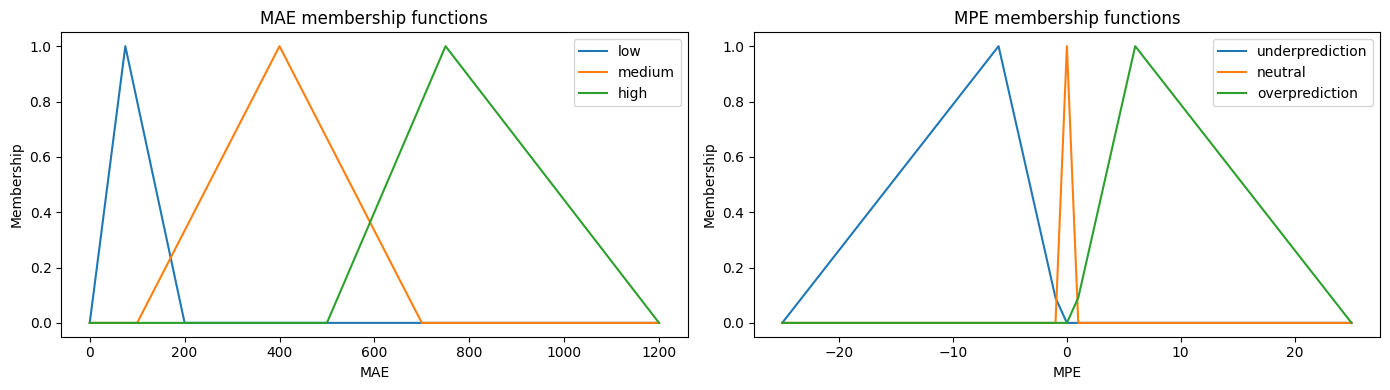

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(mae_universe, mae_low, label="low")
axes[0].plot(mae_universe, mae_medium, label="medium")
axes[0].plot(mae_universe, mae_high, label="high")
axes[0].set_title("MAE membership functions")
axes[0].set_xlabel("MAE")
axes[0].set_ylabel("Membership")
axes[0].legend()

axes[1].plot(mpe_universe, mpe_under, label="underprediction")
axes[1].plot(mpe_universe, mpe_neutral, label="neutral")
axes[1].plot(mpe_universe, mpe_over, label="overprediction")
axes[1].set_title("MPE membership functions")
axes[1].set_xlabel("MPE")
axes[1].set_ylabel("Membership")
axes[1].legend()

plt.tight_layout()
plt.show()


### Mapping Function


In [6]:
def fuzzy_label_mae(value):
    low = fuzz.interp_membership(mae_universe, mae_low, value)
    medium = fuzz.interp_membership(mae_universe, mae_medium, value)
    high = fuzz.interp_membership(mae_universe, mae_high, value)

    scores = {
        "low error": low,
        "medium error": medium,
        "high error": high
    }
    return max(scores, key=scores.get), scores

def fuzzy_label_mpe(value):
    under = fuzz.interp_membership(mpe_universe, mpe_under, value)
    neutral = fuzz.interp_membership(mpe_universe, mpe_neutral, value)
    over = fuzz.interp_membership(mpe_universe, mpe_over, value)

    scores = {
        "slight underprediction": under,
        "neutral": neutral,
        "slight overprediction": over
    }
    return max(scores, key=scores.get), scores

def map_metrics_to_labels(mae, mpe):
    mae_label, mae_scores = fuzzy_label_mae(mae)
    mpe_label, mpe_scores = fuzzy_label_mpe(mpe)
    return pd.Series({
        "MAE_Label": mae_label,
        "MPE_Label": mpe_label,
        "Combined_Label": f"{mae_label}, {mpe_label}"
    })


### Applying to Models

In [7]:
labels = metrics.apply(lambda r: map_metrics_to_labels(r["MAE"], r["MPE"]), axis=1)
metrics = pd.concat([metrics, labels], axis=1)

metrics.round(3)

,Model,MAE,RMSE,MAPE,MPE,DA,MAE_Label,MPE_Label,Combined_Label
0,Naive,781.31,948.15,5.468,5.434,0.00,high error,slight overprediction,"high error, slight overprediction"
1,Seasonal Naive,130.40,152.60,0.929,0.892,96.55,low error,neutral,"low error, neutral"
2,Linear Regression,483.29,547.70,3.472,-0.015,48.28,medium error,neutral,"medium error, neutral"
3,ETS,44.67,57.32,0.320,0.049,96.55,low error,neutral,"low error, neutral"
4,HWES (damped),62.69,79.08,0.448,0.404,96.55,low error,neutral,"low error, neutral"
5,SARIMA,45.66,59.78,0.326,0.142,96.55,low error,neutral,"low error, neutral"
6,Prophet,89.01,112.18,0.637,0.611,96.55,low error,neutral,"low error, neutral"


### Readable Output

In [8]:
for _, row in metrics.iterrows():
    print(f"{row['Model']}: {row['Combined_Label']}")

Naive: high error, slight overprediction
Seasonal Naive: low error, neutral
Linear Regression: medium error, neutral
ETS: low error, neutral
HWES (damped): low error, neutral
SARIMA: low error, neutral
Prophet: low error, neutral


In [9]:
metrics.round(3).to_csv("../src/data/session04_fuzzy_labels.csv", index=False)